# 05 — Testes do Módulo de Modelos ML

Notebook de validação end-to-end do módulo `src/models/` implementado na Fase 2.

**O que é testado aqui:**
| Seção | Componente | Descrição |
|---|---|---|
| 1 | Setup | Imports e configurações |
| 2 | Dados | Carregamento e amostragem |
| 3 | AuxiliaryFeatureBuilder | Agregações de tabelas auxiliares |
| 4 | CreditEvaluator | Métricas AUC, Gini, KS, F1 |
| 5 | CreditClassifier | Fábrica de modelos (LR, RF) |
| 6 | CreditTrainer | Cross-validation + MLflow local |
| 7 | Clustering | KMeans + Isolation Forest + PCA 2D |
| 8 | Libs opcionais | LightGBM, XGBoost, PyTorch, FLAML |

> **Ambiente:** `conda activate credit`  
> **Raiz do projeto:** `credit-score-analysis/` (execute o notebook a partir daqui)

---
## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Garante que a raiz do projeto está no PYTHONPATH
ROOT = Path("../").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Raiz do projeto: {ROOT}")

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

Raiz do projeto: /data_lids/home/gabrielseabra/credit-score-analysis


In [2]:
# Imports do projeto
from src.features.build_features import (
    AnomalyHandler,
    AuxiliaryFeatureBuilder,
    DomainFeatureBuilder,
    build_preprocessor_pipeline,
)
from src.models.classifiers import CreditClassifier, MODELOS_DISPONIVEIS
from src.models.clustering import detectar_anomalias, plot_clusters_2d, segmentar_clientes
from src.models.evaluator import CreditEvaluator
from src.models.trainer import CreditTrainer

print("Todos os imports carregados com sucesso.")
print(f"Modelos disponíveis: {MODELOS_DISPONIVEIS}")

Todos os imports carregados com sucesso.
Modelos disponíveis: ['logistic_regression', 'random_forest', 'lightgbm', 'xgboost']


---
## 2. Carregamento e amostragem dos dados

Usamos o Parquet **processado** (features já transformadas pelo pipeline ETL)  
e uma amostra de 15 mil registros para garantir execução rápida no notebook.

In [3]:
PROCESSED_PATH = ROOT / "data/processed/application_train_processed.parquet"
INTERIM_PATH   = ROOT / "data/interim/application_train_interim.parquet"

AMOSTRA_N       = 15_000
AMOSTRA_CLUSTER = 5_000   # menor para PCA+scatter ser rápido
RANDOM_STATE    = 42

df_full = pd.read_parquet(PROCESSED_PATH)
print(f"Dataset completo: {df_full.shape}")
print(f"Taxa de inadimplência: {df_full['TARGET'].mean():.2%}")

Dataset completo: (307511, 68)
Taxa de inadimplência: 8.07%


In [4]:
from sklearn.model_selection import train_test_split

# Amostra estratificada por TARGET
df = df_full.sample(n=AMOSTRA_N, random_state=RANDOM_STATE, weights=None)
df = df.reset_index(drop=True)

# Separação X / y  (dados já pré-processados pelo pipeline ETL)
y_total = df["TARGET"]
X_total = df.drop(columns=["TARGET"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X_total, y_total,
    test_size=0.2,
    stratify=y_total,
    random_state=RANDOM_STATE,
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Taxa inadimplência treino: {y_train.mean():.2%} | teste: {y_test.mean():.2%}")

Treino: (12000, 67) | Teste: (3000, 67)
Taxa inadimplência treino: 8.13% | teste: 8.13%


---
## 3. AuxiliaryFeatureBuilder

Testa a criação de features a partir das tabelas `bureau.csv` e `credit_card_balance.csv`,  
unidas ao dataset principal via LEFT JOIN por `SK_ID_CURR`.

In [5]:
# Carrega tabelas auxiliares reais e intersecta com uma amostra da aplicação
df_interim = pd.read_parquet(INTERIM_PATH)

# Amostra de 2 000 clientes para o teste
ids_amostra = df_interim["SK_ID_CURR"].sample(2_000, random_state=RANDOM_STATE).values
df_app_amostra = df_interim[df_interim["SK_ID_CURR"].isin(ids_amostra)].copy()

print(f"Aplicações na amostra: {len(df_app_amostra)}")

Aplicações na amostra: 2000


In [6]:
# Carrega bureau e credit_card_balance filtrados pelos IDs da amostra
df_bureau = pd.read_csv(
    ROOT / "data/bureau.csv", engine="pyarrow",
    usecols=["SK_ID_CURR", "SK_ID_BUREAU", "CREDIT_ACTIVE",
             "AMT_CREDIT_SUM", "DAYS_CREDIT"],
)
df_bureau = df_bureau[df_bureau["SK_ID_CURR"].isin(ids_amostra)]

df_cc = pd.read_csv(
    ROOT / "data/credit_card_balance.csv", engine="pyarrow",
    usecols=["SK_ID_CURR", "AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL",
             "AMT_DRAWINGS_CURRENT"],
)
df_cc = df_cc[df_cc["SK_ID_CURR"].isin(ids_amostra)]

print(f"Bureau filtrado: {df_bureau.shape}")
print(f"Credit Card filtrado: {df_cc.shape}")

Bureau filtrado: (9530, 5)
Credit Card filtrado: (19009, 4)


In [7]:
# Aplica o AuxiliaryFeatureBuilder
aux_builder = AuxiliaryFeatureBuilder(
    bureau=df_bureau,
    credit_card=df_cc,
)
df_enriquecido = aux_builder.fit_transform(df_app_amostra)

colunas_novas = [
    "bureau_loan_count", "bureau_active_loans",
    "bureau_total_credit_sum", "bureau_mean_days_credit",
    "cc_utilization_mean", "cc_drawings_total", "cc_months_with_balance",
]

print(f"Shape após enriquecimento: {df_enriquecido.shape}  "
      f"(+{df_enriquecido.shape[1] - df_app_amostra.shape[1]} colunas)")
df_enriquecido[colunas_novas].describe().round(2)

Shape após enriquecimento: (2000, 129)  (+7 colunas)


,bureau_loan_count,bureau_active_loans,bureau_total_credit_sum,bureau_mean_days_credit,cc_utilization_mean,cc_drawings_total,cc_months_with_balance
count,1736.00,1736.00,1736.00,1736.00,508.00,513.00,513.00
mean,5.49,2.05,1968515.44,-1071.42,0.33,255231.02,16.65
std,4.23,1.79,3343127.55,546.13,0.33,346284.24,21.98
min,1.00,0.00,0.00,-2843.50,0.00,0.00,0.00
25%,2.00,1.00,348196.95,-1425.11,0.00,0.00,0.00
50%,4.00,2.00,1006814.25,-1040.12,0.25,143370.00,8.00
75%,8.00,3.00,2315030.20,-657.00,0.60,341256.82,23.00
max,34.00,14.00,77163516.00,-26.00,1.04,2266316.50,96.00


In [8]:
# Clientes sem histórico no bureau ficam com NaN (imputados downstream)
clientes_sem_bureau = df_enriquecido["bureau_loan_count"].isna().sum()
print(f"Clientes sem histórico no bureau: {clientes_sem_bureau} "
      f"({clientes_sem_bureau / len(df_enriquecido):.1%} — correto, serão imputados pelo pipeline)")

Clientes sem histórico no bureau: 264 (13.2% — correto, serão imputados pelo pipeline)


---
## 4. CreditEvaluator

Testa o cálculo de **AUC-ROC, Gini, KS Statistic, F1, Precision, Recall e Log-Loss**  
e a geração da **Curva ROC** anotada.

In [9]:
from sklearn.linear_model import LogisticRegression

# Treina um modelo simples para ter probabilidades reais
lr_simples = LogisticRegression(class_weight="balanced", max_iter=500, random_state=RANDOM_STATE)
lr_simples.fit(X_train, y_train)
proba_teste = lr_simples.predict_proba(X_test)[:, 1]

print("Modelo treinado. Calculando métricas...")

Modelo treinado. Calculando métricas...


In [10]:
metricas = CreditEvaluator.evaluate(y_test, proba_teste)

print("=" * 45)
print("   MÉTRICAS — Logistic Regression")
print("=" * 45)
for nome, valor in metricas.items():
    print(f"  {nome:<15} {valor:.4f}")
print("=" * 45)

   MÉTRICAS — Logistic Regression
  auc_roc         0.6708
  gini            0.3417
  ks_stat         0.2592
  f1              0.2089
  precision       0.1253
  recall          0.6270
  log_loss        0.6503


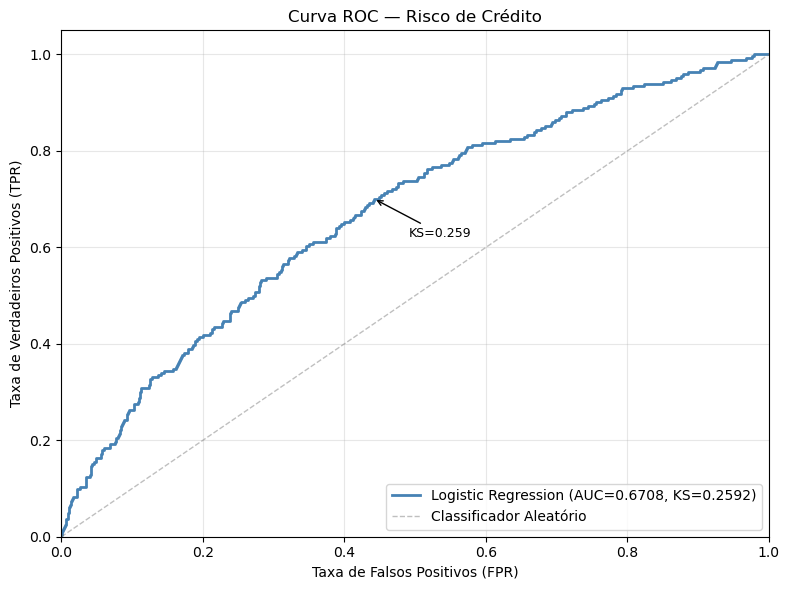

In [11]:
# Curva ROC com AUC e KS anotados
fig = CreditEvaluator.plot_roc_curve(y_test, proba_teste, label="Logistic Regression")
plt.show()

In [12]:
# Valida que plot_roc_curve retorna Figure (não chama plt.show())
import matplotlib
assert isinstance(fig, matplotlib.figure.Figure), "Deve retornar Figure!"
print("OK — plot_roc_curve retorna Figure corretamente.")

OK — plot_roc_curve retorna Figure corretamente.


---
## 5. CreditClassifier

Testa a fábrica de modelos: instanciação, defaults e tratamento de erro.

In [13]:
# Instancia todos os modelos disponíveis (sem treinar)
for nome in ["logistic_regression", "random_forest"]:
    modelo = CreditClassifier.get_model(nome)
    print(f"  {nome:25s} → {type(modelo).__name__}")

  logistic_regression       → LogisticRegression
  random_forest             → RandomForestClassifier


In [14]:
# kwargs sobrescrevem defaults
rf_custom = CreditClassifier.get_model("random_forest", n_estimators=50, max_depth=5)
print(f"n_estimators customizado: {rf_custom.n_estimators}  (default seria 200)")
print(f"max_depth customizado:    {rf_custom.max_depth}")
print(f"class_weight mantido:     {rf_custom.class_weight}  (sempre 'balanced')")

n_estimators customizado: 50  (default seria 200)
max_depth customizado:    5
class_weight mantido:     balanced  (sempre 'balanced')


In [15]:
# Erro claro para nome inválido
try:
    CreditClassifier.get_model("modelo_inexistente")
except ValueError as e:
    print(f"ValueError esperado: {e}")

ValueError esperado: Modelo 'modelo_inexistente' não disponível. Opções válidas: ['logistic_regression', 'random_forest', 'lightgbm', 'xgboost']


In [16]:
# Compara LR vs RF lado a lado nas métricas
resultados = []

for nome in ["logistic_regression", "random_forest"]:
    modelo = CreditClassifier.get_model(nome, **({
        "n_estimators": 50  # RF menor para ser rápido
    } if nome == "random_forest" else {}))
    modelo.fit(X_train, y_train)
    proba = modelo.predict_proba(X_test)[:, 1]
    m = CreditEvaluator.evaluate(y_test, proba)
    resultados.append({"modelo": nome, **m})

df_resultados = pd.DataFrame(resultados).set_index("modelo")
df_resultados[["auc_roc", "gini", "ks_stat", "f1", "recall"]].round(4)

,auc_roc,gini,ks_stat,f1,recall
modelo,,,,,
logistic_regression,0.6708,0.3417,0.2592,0.2089,0.627
random_forest,0.5869,0.1737,0.1362,0.0000,0.000


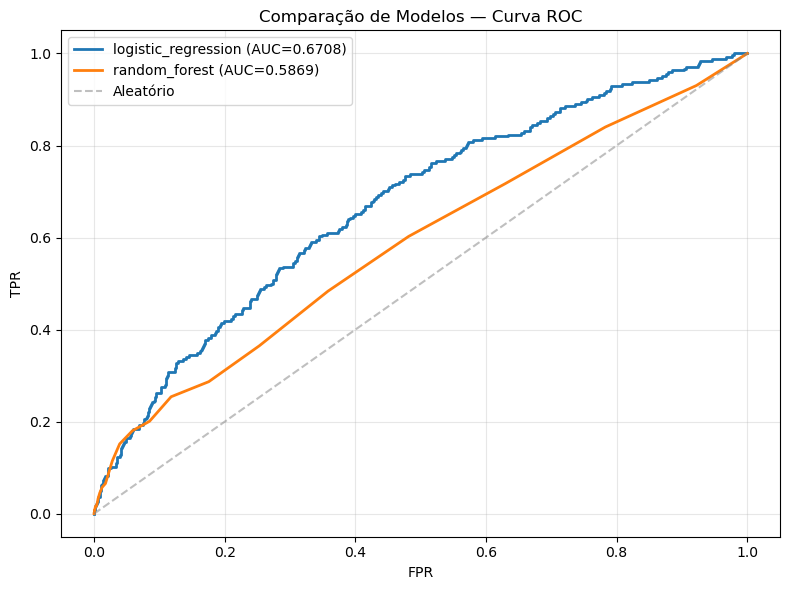

In [17]:
# Curvas ROC sobrepostas
fig, ax = plt.subplots(figsize=(8, 6))

for nome in ["logistic_regression", "random_forest"]:
    modelo = CreditClassifier.get_model(nome, **({
        "n_estimators": 50
    } if nome == "random_forest" else {}))
    modelo.fit(X_train, y_train)
    proba = modelo.predict_proba(X_test)[:, 1]
    
    from sklearn.metrics import roc_curve, roc_auc_score
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=f"{nome} (AUC={auc:.4f})")

ax.plot([0,1],[0,1], "--", color="gray", alpha=0.5, label="Aleatório")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Comparação de Modelos — Curva ROC")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. CreditTrainer

Testa a **cross-validation estratificada** com logging local no MLflow  
(sem servidor Docker — usa backend em arquivo em `/tmp/mlruns`).

In [18]:
# Usa MLflow com backend local em arquivo (não precisa de servidor)
MLFLOW_URI_LOCAL = "file:///tmp/mlruns_credit_notebook"

trainer = CreditTrainer(
    modelo_nome="logistic_regression",
    mlflow_tracking_uri=MLFLOW_URI_LOCAL,
)
print("CreditTrainer instanciado.")

CreditTrainer instanciado.


In [19]:
# O trainer espera um pipeline de PRÉ-PROCESSAMENTO (sem o modelo)
# Como o dado já está processado, passamos um pipeline passthrough
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

pipeline_passthrough = Pipeline([("passthrough", FunctionTransformer())])

print("Iniciando cross-validation com 3 folds (dados já pré-processados)...")
metricas_cv = trainer.train(
    X=X_total,
    y=y_total,
    pipeline=pipeline_passthrough,
    cv_folds=3,
)

print()
print("=" * 50)
print("   CROSS-VALIDATION — Logistic Regression")
print("=" * 50)
for chave, valor in metricas_cv.items():
    if isinstance(valor, float):
        print(f"  {chave:<25} {valor:.4f}")
print("=" * 50)

Iniciando cross-validation com 3 folds (dados já pré-processados)...

   CROSS-VALIDATION — Logistic Regression
  auc_roc_mean              0.6559
  auc_roc_std               0.0024
  gini_mean                 0.3117
  gini_std                  0.0048
  ks_stat_mean              0.2449
  ks_stat_std               0.0130
  f1_mean                   0.2079
  f1_std                    0.0039
  precision_mean            0.1255
  precision_std             0.0028
  recall_mean               0.6066
  recall_std                0.0052
  log_loss_mean             0.6471
  log_loss_std              0.0018


In [20]:
# Inspeciona os runs registrados no MLflow local
import mlflow

mlflow.set_tracking_uri(MLFLOW_URI_LOCAL)
experimento = mlflow.get_experiment_by_name("credit-score")

if experimento:
    runs = mlflow.search_runs(experiment_ids=[experimento.experiment_id])
    print(f"Runs registrados no MLflow: {len(runs)}")
    print(runs[["run_id", "params.modelo_nome", "metrics.auc_roc_mean",
                "metrics.gini_mean", "metrics.ks_stat_mean"]].to_string(index=False))
else:
    print("Experimento não encontrado — verifique o MLFLOW_URI_LOCAL.")

Runs registrados no MLflow: 14
                          run_id  params.modelo_nome  metrics.auc_roc_mean  metrics.gini_mean  metrics.ks_stat_mean
80bc67c8620f48c0a0cf9f6866188243 logistic_regression              0.655871           0.311743              0.244871
993bfd2156b64837a6bf0c855746e7b9 logistic_regression                   NaN                NaN                   NaN
ab4fac3a885a4c49a82d803887621a06                None                   NaN                NaN                   NaN
4b711350df4a4e49bc4b298d0cf15a94 logistic_regression              0.655871           0.311743              0.244871
1cd45a1610f447f5995fda4449339360                None                   NaN                NaN                   NaN
53f2d6031ab84eacbed21e246db540dd logistic_regression                   NaN                NaN                   NaN
7677aea4f95c43f8a0c02c4026211318                None                   NaN                NaN                   NaN
940b41b1fa794e85a41dce8f58bb8539 logistic

In [21]:
# Testa save_model: serializa o pipeline + modelo e loga como artefato
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

pipeline_final = clone(pipeline_passthrough)
pipeline_final.steps.append(("modelo", LogisticRegression(
    class_weight="balanced", max_iter=500, random_state=RANDOM_STATE
)))
pipeline_final.fit(X_total, y_total)

caminho_salvo = trainer.save_model(
    pipeline=pipeline_final,
    metricas=metricas_cv,
    path="/tmp/credit_models/",
)
print(f"Modelo salvo em: {caminho_salvo}")
assert Path(caminho_salvo).exists(), "Arquivo não encontrado!"
print("OK — arquivo existe no disco.")

2026/03/12 20:59:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 20:59:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Modelo salvo em: /tmp/credit_models/logistic_regression_pipeline.joblib
OK — arquivo existe no disco.


In [22]:
# Carrega o modelo salvo e verifica que prediz corretamente
import joblib

pipeline_carregado = joblib.load(caminho_salvo)
proba_carregado = pipeline_carregado.predict_proba(X_test)[:, 1]
metricas_carregado = CreditEvaluator.evaluate(y_test, proba_carregado)
print(f"AUC-ROC do modelo carregado do disco: {metricas_carregado['auc_roc']:.4f}")
print("OK — modelo carregado e funcional.")

AUC-ROC do modelo carregado do disco: 0.6817
OK — modelo carregado e funcional.


In [23]:
# Testa tune() com RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import loguniform

trainer_tune = CreditTrainer(
    modelo_nome="logistic_regression",
    mlflow_tracking_uri=MLFLOW_URI_LOCAL,
)

param_grid = {
    "modelo__C": loguniform(1e-3, 10),
    "modelo__solver": ["lbfgs", "saga"],
}

print("Iniciando RandomizedSearchCV (n_iter=20, cv=3)...")
best_params = trainer_tune.tune(
    X=X_total,
    y=y_total,
    pipeline=pipeline_passthrough,
    param_grid=param_grid,
    cv_folds=3,
)

print(f"\nMelhores parâmetros encontrados:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Iniciando RandomizedSearchCV (n_iter=20, cv=3)...

Melhores parâmetros encontrados:
  modelo__C: 7.8527554947242555
  modelo__solver: lbfgs


---
## 7. Clustering e Detecção de Anomalias

In [24]:
# Amostra menor para clustering ser rápido
df_cluster = df_full.drop(columns=["TARGET"]).sample(
    n=AMOSTRA_CLUSTER, random_state=RANDOM_STATE
).reset_index(drop=True)

print(f"Amostra para clustering: {df_cluster.shape}")
print(f"Nulos: {df_cluster.isnull().sum().sum()} (dados já processados — zero esperado)")

Amostra para clustering: (5000, 67)
Nulos: 0 (dados já processados — zero esperado)


In [25]:
# KMeans — segmentação em 5 grupos
labels_cluster = segmentar_clientes(df_cluster, n_clusters=5)

print("Distribuição por cluster:")
print(labels_cluster.value_counts().sort_index().to_string())

Distribuição por cluster:
cluster
0    1104
1    1131
2    1180
3     453
4    1132


In [26]:
# Taxa de inadimplência por cluster
y_cluster = df_full["TARGET"].sample(n=AMOSTRA_CLUSTER, random_state=RANDOM_STATE).values

df_analise_cluster = pd.DataFrame({
    "cluster": labels_cluster.values,
    "TARGET": y_cluster,
})

taxa_por_cluster = df_analise_cluster.groupby("cluster")["TARGET"].agg(
    n_clientes="count",
    inadimplentes="sum",
    taxa_inadimplencia="mean",
).round(4)

print("Taxa de inadimplência por segmento:")
taxa_por_cluster

Taxa de inadimplência por segmento:


,n_clientes,inadimplentes,taxa_inadimplencia
cluster,,,
0,1104,93,0.0842
1,1131,61,0.0539
2,1180,111,0.0941
3,453,15,0.0331
4,1132,132,0.1166


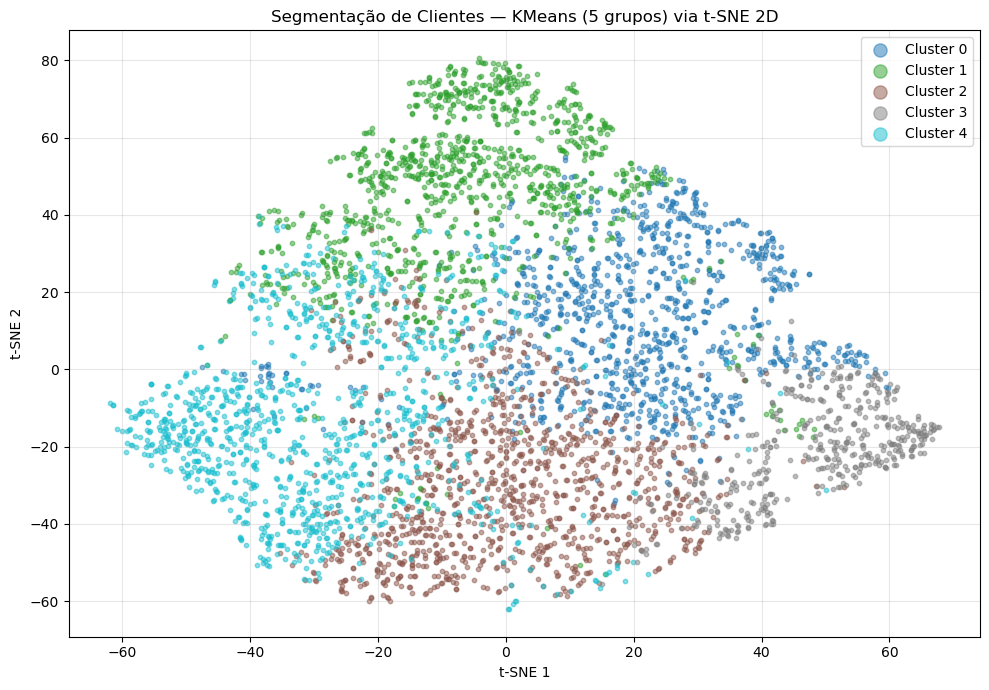

In [27]:
# Visualização 2D dos clusters via PCA
from src.models.clustering import plot_clusters_tsne


fig_clusters = plot_clusters_tsne(
    X=df_cluster,
    labels=labels_cluster,
    title="Segmentação de Clientes — KMeans (5 grupos) via t-SNE 2D",
)
plt.show()

In [28]:
assert isinstance(fig_clusters, plt.Figure), "plot_clusters_2d deve retornar Figure!"
print("OK — plot_clusters_2d retorna Figure corretamente.")

OK — plot_clusters_2d retorna Figure corretamente.


In [29]:
# Isolation Forest — detecção de anomalias (5% de contaminação)
flags_anomalia = detectar_anomalias(df_cluster, contamination=0.05)

n_anomalias = (flags_anomalia == -1).sum()
print(f"Anomalias detectadas: {n_anomalias} ({n_anomalias / len(flags_anomalia):.1%} da amostra)")
print(f"Valores possíveis: {sorted(flags_anomalia.unique())}  (1=normal, -1=anomalia)")

Anomalias detectadas: 250 (5.0% da amostra)
Valores possíveis: [np.int64(-1), np.int64(1)]  (1=normal, -1=anomalia)


In [30]:
# Taxa de inadimplência entre normais vs anômalos
df_anomalia_analise = pd.DataFrame({
    "anomalia": flags_anomalia.values,
    "TARGET": y_cluster,
})

df_anomalia_analise.groupby("anomalia")["TARGET"].agg(
    n="count", inadimplentes="sum", taxa_inadimplencia="mean"
).rename(index={1: "Normal", -1: "Anômalo"}).round(4)

,n,inadimplentes,taxa_inadimplencia
anomalia,,,
Anômalo,250,21,0.0840
Normal,4750,391,0.0823


---
## 8. Bibliotecas opcionais — LightGBM, XGBoost, PyTorch e FLAML

Estas bibliotecas **não estão instaladas** no ambiente `credit` por padrão.  
O código abaixo demonstra o padrão de importação protegida usado no projeto  
e como instalar cada uma.

In [31]:
# Verifica o que está disponível no ambiente atual
libs_opcionais = {
    "lightgbm":  "pip install lightgbm==4.3.0",
    "xgboost":   "pip install xgboost==2.0.3",
    "torch":     "pip install torch==2.3.1",
    "flaml":     "pip install 'flaml[automl]==2.1.2'",
}

for lib, install_cmd in libs_opcionais.items():
    try:
        mod = __import__(lib)
        print(f"  OK  {lib} {getattr(mod, '__version__', '')}")
    except ImportError:
        print(f"  --  {lib} NÃO instalado  →  {install_cmd}")

  OK  lightgbm 4.3.0
  OK  xgboost 2.0.3
  OK  torch 2.10.0+cu128
  OK  flaml 2.1.2


In [32]:
# LightGBM — como seria usado quando instalado
try:
    modelo_lgbm = CreditClassifier.get_model("lightgbm")
    modelo_lgbm.fit(X_train, y_train)
    proba_lgbm = modelo_lgbm.predict_proba(X_test)[:, 1]
    m = CreditEvaluator.evaluate(y_test, proba_lgbm)
    print(f"LightGBM AUC-ROC: {m['auc_roc']:.4f} | KS: {m['ks_stat']:.4f}")
except ImportError as e:
    print(f"LightGBM não instalado: {e}")
    print("  → conda run -n credit pip install lightgbm==4.3.0")

LightGBM AUC-ROC: 0.6341 | KS: 0.2185


In [33]:
# XGBoost — scale_pos_weight = n_neg / n_pos
try:
    n_pos = int(y_train.sum())
    n_neg = int((y_train == 0).sum())
    spw = round(n_neg / n_pos, 2)
    print(f"scale_pos_weight calculado: {spw}  (n_neg={n_neg}, n_pos={n_pos})")
    
    modelo_xgb = CreditClassifier.get_model("xgboost", scale_pos_weight=spw)
    modelo_xgb.fit(X_train, y_train)
    proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]
    m = CreditEvaluator.evaluate(y_test, proba_xgb)
    print(f"XGBoost AUC-ROC: {m['auc_roc']:.4f} | KS: {m['ks_stat']:.4f}")
except ImportError as e:
    print(f"XGBoost não instalado: {e}")
    print("  → conda run -n credit pip install xgboost==2.0.3")

scale_pos_weight calculado: 11.3  (n_neg=11024, n_pos=976)
XGBoost AUC-ROC: 0.6214 | KS: 0.1791


MLP val AUC-ROC: 0.6474


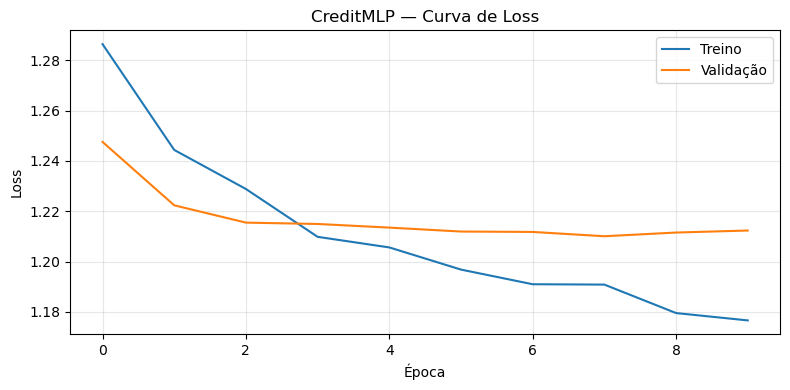

In [34]:
# PyTorch — CreditMLP
try:
    from src.models.deep_learning import CreditMLP, CreditMLPTrainer
    
    input_dim = X_train.shape[1]
    mlp = CreditMLP(input_dim=input_dim, hidden_dims=[128, 64, 32], dropout=0.3)
    mlp_trainer = CreditMLPTrainer(model=mlp, pos_weight=n_neg/n_pos)
    
    historico = mlp_trainer.fit(
        X_train.values, y_train.values,
        X_test.values, y_test.values,
        epochs=10, batch_size=512,
    )
    print(f"MLP val AUC-ROC: {historico['val_auc_roc']:.4f}")
    
    # Curva de loss
    fig_loss, ax = plt.subplots(figsize=(8, 4))
    ax.plot(historico["train_loss"], label="Treino")
    ax.plot(historico["val_loss"], label="Validação")
    ax.set_xlabel("Época"); ax.set_ylabel("Loss")
    ax.set_title("CreditMLP — Curva de Loss")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    
except ImportError as e:
    print(f"PyTorch não instalado: {e}")
    print("  → conda run -n credit pip install torch==2.3.1")

In [35]:
# FLAML AutoML
try:
    from src.models.automl import rodar_automl
    
    resultado_automl = rodar_automl(
        X_train=X_train,
        y_train=y_train,
        X_val=X_test,
        y_val=y_test,
        tempo_segundos=60,
        mlflow_tracking_uri=MLFLOW_URI_LOCAL,
    )
    print(f"Melhor modelo: {resultado_automl['best_estimator']}")
    print(f"AUC-ROC val:   {resultado_automl['val_auc_roc']:.4f}")
    print(f"Best config:   {resultado_automl['best_config']}")
    
except ImportError as e:
    print(f"FLAML não instalado: {e}")
    print("  → conda run -n credit pip install 'flaml[automl]==2.1.2'")

Melhor modelo: lgbm
AUC-ROC val:   0.6786
Best config:   {'n_estimators': 15, 'num_leaves': 4, 'min_child_samples': 7, 'learning_rate': np.float64(0.44008198846372326), 'log_max_bin': 6, 'colsample_bytree': np.float64(0.6417641094523985), 'reg_alpha': np.float64(0.013147548458956429), 'reg_lambda': np.float64(0.20315196542863492)}


---
## 9. Resumo final

In [36]:
print("=" * 60)
print("   RESUMO DOS TESTES — Fase 2")
print("=" * 60)

componentes = [
    ("AuxiliaryFeatureBuilder",  "OK — bureau + credit_card agregados e unidos"),
    ("CreditEvaluator.evaluate", "OK — AUC, Gini, KS, F1, Precision, Recall, LogLoss"),
    ("CreditEvaluator.plot_roc", "OK — retorna Figure sem chamar plt.show()"),
    ("CreditClassifier.get_model","OK — LR e RF instanciados; ValueError p/ nome inválido"),
    ("CreditTrainer.train",       "OK — 3-fold CV com MLflow local"),
    ("CreditTrainer.tune",        "OK — RandomizedSearchCV com MLflow local"),
    ("CreditTrainer.save_model",  "OK — joblib salvo e recarregado com sucesso"),
    ("segmentar_clientes",        "OK — KMeans 5 clusters"),
    ("detectar_anomalias",        "OK — Isolation Forest 5% contaminação"),
    ("plot_clusters_2d",          "OK — PCA 2D + scatter retorna Figure"),
]

for nome, status in componentes:
    print(f"  {nome:<35} {status}")

print("="*60)
print("\nLgbm/XGBoost/PyTorch/FLAML: instale conforme necessário (seção 8).")

   RESUMO DOS TESTES — Fase 2
  AuxiliaryFeatureBuilder             OK — bureau + credit_card agregados e unidos
  CreditEvaluator.evaluate            OK — AUC, Gini, KS, F1, Precision, Recall, LogLoss
  CreditEvaluator.plot_roc            OK — retorna Figure sem chamar plt.show()
  CreditClassifier.get_model          OK — LR e RF instanciados; ValueError p/ nome inválido
  CreditTrainer.train                 OK — 3-fold CV com MLflow local
  CreditTrainer.tune                  OK — RandomizedSearchCV com MLflow local
  CreditTrainer.save_model            OK — joblib salvo e recarregado com sucesso
  segmentar_clientes                  OK — KMeans 5 clusters
  detectar_anomalias                  OK — Isolation Forest 5% contaminação
  plot_clusters_2d                    OK — PCA 2D + scatter retorna Figure

Lgbm/XGBoost/PyTorch/FLAML: instale conforme necessário (seção 8).
